In [3]:
# 1_ Analyse de rentabilité d’un dataset e-commerce

## 2_ Objectif :
## Ce projet vise à analyser un dataset de ventes e-commerce afin de :

## - mesurer la rentabilité
## - analyser les annulations et retours
## - comparer les canaux logistiques
## - identifier les catégories les plus importantes
## - produire des recommandations business

## Dataset
## - `Sale Report.csv` : stock / référentiel produit
## - `Amazon Sale Report.csv` : transactions de ventes

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)
pd.set_option("display.float_format", "{:,.2f}".format)

In [5]:
# Chargement des fichiers
stock_df = pd.read_csv("Sale Report.csv")
sales_df = pd.read_csv("Amazon Sale Report.csv")

C:\Users\boudo\AppData\Local\Temp\ipykernel_13464\987355688.py:3: DtypeWarning: Columns (23) have mixed types. Specify dtype option on import or set low_memory=False.
  sales_df = pd.read_csv("Amazon Sale Report.csv")


In [6]:
#j'affiche le nombre de lignes et colonnes 

print("Stock shape :", stock_df.shape)
print("Sales shape :", sales_df.shape)

Stock shape : (9271, 7)
Sales shape : (128975, 24)


In [7]:
stock_df.head()

,index,SKU Code,Design No.,Stock,Category,Size,Color
0,0,AN201-RED-L,AN201,5.00,AN : LEGGINGS,L,Red
1,1,AN201-RED-M,AN201,5.00,AN : LEGGINGS,M,Red
2,2,AN201-RED-S,AN201,3.00,AN : LEGGINGS,S,Red
3,3,AN201-RED-XL,AN201,6.00,AN : LEGGINGS,XL,Red
4,4,AN201-RED-XXL,AN201,3.00,AN : LEGGINGS,XXL,Red


In [8]:
stock_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9271 entries, 0 to 9270
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   index       9271 non-null   int64  
 1   SKU Code    9188 non-null   object 
 2   Design No.  9235 non-null   object 
 3   Stock       9235 non-null   float64
 4   Category    9226 non-null   object 
 5   Size        9235 non-null   object 
 6   Color       9226 non-null   object 
dtypes: float64(1), int64(1), object(5)
memory usage: 507.1+ KB


In [9]:
## Analyse des valeurs manquantes

#Avant toute analyse, il est nécessaire d’évaluer la qualité des données.
#Cette étape permet d’identifier les colonnes contenant des valeurs manquantes
#et d’estimer leur impact sur l'analyse.

In [10]:
# Compte le nombre de valeurs manquantes (NaN) pour chaque colonne
stock_df.isna().sum()

index          0
SKU Code      83
Design No.    36
Stock         36
Category      45
Size          36
Color         45
dtype: int64

In [11]:
#je détermine le pourcentage de valeurs manquantes par colonne

(stock_df.isna().sum() / len(stock_df) * 100).sort_values(ascending=False)

SKU Code     0.90
Category     0.49
Color        0.49
Design No.   0.39
Stock        0.39
Size         0.39
index        0.00
dtype: float64

In [12]:
stock_df.shape

(9271, 7)

In [13]:
# Liste des colonnes principales qu'on considère comme essentielles
main_stock_cols = ["SKU Code", "Design No.", "Stock", "Category", "Size", "Color"]

# On supprime les lignes où toutes les colonnes principales sont vides
# how="all" signifie : supprimer seulement si toutes ces colonnes sont NaN
stock_df = stock_df.dropna(subset=main_stock_cols, how="all").copy()

# On réinitialise l'index après suppression de lignes
stock_df.reset_index(drop=True, inplace=True)

# On affiche la nouvelle taille du DataFrame
stock_df.shape

(9235, 7)

In [14]:
# je Vérifie si une colonne "index" existe dans le DataFrame
if "index" in stock_df.columns:
    # Si elle existe, on la supprime
    stock_df = stock_df.drop(columns=["index"])

In [15]:
stock_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9235 entries, 0 to 9234
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   SKU Code    9188 non-null   object 
 1   Design No.  9235 non-null   object 
 2   Stock       9235 non-null   float64
 3   Category    9226 non-null   object 
 4   Size        9235 non-null   object 
 5   Color       9226 non-null   object 
dtypes: float64(1), object(5)
memory usage: 433.0+ KB


In [16]:
# Convertit la colonne Stock en format numérique
# errors="coerce" transforme les valeurs non convertibles en NaN

stock_df["Stock"] = pd.to_numeric(stock_df["Stock"], errors="coerce")

In [17]:
# Recompte les valeurs manquantes après nettoyage
stock_df.isna().sum()

SKU Code      47
Design No.     0
Stock          0
Category       9
Size           0
Color          9
dtype: int64

In [18]:
# Calcule la somme totale du stock disponible
stock_total = stock_df["Stock"].sum()

# Affiche le résultat
stock_total

242386.0

In [19]:
# je Regroupe les données par catégorie
# Puis j'additionne le stock pour chaque catégorie
# je trie du plus grand au plus petit
stock_by_category = (
    stock_df.groupby("Category", dropna=False)["Stock"]
    .sum()
    .sort_values(ascending=False)
)

stock_by_category

Category
KURTA                  114,339.00
KURTA SET               47,684.00
SET                     24,643.00
TOP                     16,609.00
DRESS                   11,675.00
BLOUSE                   7,932.00
PANT                     3,436.00
NIGHT WEAR               3,288.00
TUNIC                    2,967.00
SAREE                    2,777.00
KURTI                    1,605.00
SHARARA                  1,190.00
PALAZZO                    963.00
LEHENGA CHOLI              736.00
AN : LEGGINGS              715.00
SKIRT                      673.00
CROP TOP WITH PLAZZO       617.00
CROP TOP                   405.00
CARDIGAN                    58.00
BOTTOM                      41.00
JUMPSUIT                    33.00
NaN                          0.00
Name: Stock, dtype: float64

In [20]:
# je Calcule le pourcentage que représente chaque catégorie dans le stock total
stock_share_category = (stock_by_category / stock_by_category.sum() * 100).round(2)

stock_share_category

Category
KURTA                  47.17
KURTA SET              19.67
SET                    10.17
TOP                     6.85
DRESS                   4.82
BLOUSE                  3.27
PANT                    1.42
NIGHT WEAR              1.36
TUNIC                   1.22
SAREE                   1.15
KURTI                   0.66
SHARARA                 0.49
PALAZZO                 0.40
LEHENGA CHOLI           0.30
AN : LEGGINGS           0.29
SKIRT                   0.28
CROP TOP WITH PLAZZO    0.25
CROP TOP                0.17
CARDIGAN                0.02
BOTTOM                  0.02
JUMPSUIT                0.01
NaN                     0.00
Name: Stock, dtype: float64

In [21]:
# Analyse du stock total par taille
stock_by_size = (
    stock_df.groupby("Size", dropna=False)["Stock"]
    .sum()
    .sort_values(ascending=False)
)

stock_by_size

Size
S      41,872.00
M      37,163.00
XS     35,082.00
L      32,953.00
XL     32,046.00
XXL    30,683.00
XXXL   21,596.00
FREE    7,841.00
6XL     1,111.00
5XL     1,061.00
4XL       978.00
Name: Stock, dtype: float64

In [22]:
# Affiche les 5 premières lignes du fichier des ventes
sales_df.head()

,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,Size,ASIN,Courier Status,Qty,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Unnamed: 22
0,0,405-8078784-5731545,04-30-22,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,S,B09KXVBD7Z,NaN,0,INR,647.62,MUMBAI,MAHARASHTRA,"400,081.00",IN,NaN,False,Easy Ship,NaN
1,1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,3XL,B09K3WFS32,Shipped,1,INR,406.00,BENGALURU,KARNATAKA,"560,085.00",IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
2,2,404-0687676-7273146,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,XL,B07WV4JV4D,Shipped,1,INR,329.00,NAVI MUMBAI,MAHARASHTRA,"410,210.00",IN,IN Core Free Shipping 2015/04/08 23-48-5-108,True,NaN,NaN
3,3,403-9615377-8133951,04-30-22,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,L,B099NRCT7B,NaN,0,INR,753.33,PUDUCHERRY,PUDUCHERRY,"605,008.00",IN,NaN,False,Easy Ship,NaN
4,4,407-1069790-7240320,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,3XL,B098714BZP,Shipped,1,INR,574.00,CHENNAI,TAMIL NADU,"600,073.00",IN,NaN,False,NaN,NaN


In [23]:
# Donne le résumé technique du dataset ventes
sales_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128975 entries, 0 to 128974
Data columns (total 24 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   index               128975 non-null  int64  
 1   Order ID            128975 non-null  object 
 2   Date                128975 non-null  object 
 3   Status              128975 non-null  object 
 4   Fulfilment          128975 non-null  object 
 5   Sales Channel       128975 non-null  object 
 6   ship-service-level  128975 non-null  object 
 7   Style               128975 non-null  object 
 8   SKU                 128975 non-null  object 
 9   Category            128975 non-null  object 
 10  Size                128975 non-null  object 
 11  ASIN                128975 non-null  object 
 12  Courier Status      122103 non-null  object 
 13  Qty                 128975 non-null  int64  
 14  currency            121180 non-null  object 
 15  Amount              121180 non-nul

In [24]:
# Liste des colonnes jugées utiles pour l'analyse business
use_cols = [
    "Order ID", "Date", "Status", "SKU", "Category", "Size",
    "Qty", "Amount", "Fulfilment", "ship-city", "ship-state"
]

# On crée un nouveau DataFrame plus léger contenant uniquement les colonnes utiles
sales = sales_df[use_cols].copy()

sales.head()

,Order ID,Date,Status,SKU,Category,Size,Qty,Amount,Fulfilment,ship-city,ship-state
0,405-8078784-5731545,04-30-22,Cancelled,SET389-KR-NP-S,Set,S,0,647.62,Merchant,MUMBAI,MAHARASHTRA
1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,JNE3781-KR-XXXL,kurta,3XL,1,406.00,Merchant,BENGALURU,KARNATAKA
2,404-0687676-7273146,04-30-22,Shipped,JNE3371-KR-XL,kurta,XL,1,329.00,Amazon,NAVI MUMBAI,MAHARASHTRA
3,403-9615377-8133951,04-30-22,Cancelled,J0341-DR-L,Western Dress,L,0,753.33,Merchant,PUDUCHERRY,PUDUCHERRY
4,407-1069790-7240320,04-30-22,Shipped,JNE3671-TU-XXXL,Top,3XL,1,574.00,Amazon,CHENNAI,TAMIL NADU


In [25]:
# Convertit la colonne Date en vrai format date
# errors="coerce" transforme les dates invalides en NaT
sales["Date"] = pd.to_datetime(sales["Date"], errors="coerce")

# Convertit la quantité en numérique
sales["Qty"] = pd.to_numeric(sales["Qty"], errors="coerce")

# Convertit le montant en numérique
sales["Amount"] = pd.to_numeric(sales["Amount"], errors="coerce")

C:\Users\boudo\AppData\Local\Temp\ipykernel_13464\1778730200.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  sales["Date"] = pd.to_datetime(sales["Date"], errors="coerce")


In [26]:
# Vérifie que les types ont bien changé
sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128975 entries, 0 to 128974
Data columns (total 11 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   Order ID    128975 non-null  object        
 1   Date        128975 non-null  datetime64[ns]
 2   Status      128975 non-null  object        
 3   SKU         128975 non-null  object        
 4   Category    128975 non-null  object        
 5   Size        128975 non-null  object        
 6   Qty         128975 non-null  int64         
 7   Amount      121180 non-null  float64       
 8   Fulfilment  128975 non-null  object        
 9   ship-city   128942 non-null  object        
 10  ship-state  128942 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(8)
memory usage: 10.8+ MB


In [27]:
# Vérifie les valeurs manquantes après conversion
sales.isna().sum()

Order ID         0
Date             0
Status           0
SKU              0
Category         0
Size             0
Qty              0
Amount        7795
Fulfilment       0
ship-city       33
ship-state      33
dtype: int64

In [28]:
# Compte le nombre d'occurrences de chaque statut
sales["Status"].value_counts(dropna=False)

Status
Shipped                          77804
Shipped - Delivered to Buyer     28769
Cancelled                        18332
Shipped - Returned to Seller      1953
Shipped - Picked Up                973
Pending                            658
Pending - Waiting for Pick Up      281
Shipped - Returning to Seller      145
Shipped - Out for Delivery          35
Shipped - Rejected by Buyer         11
Shipping                             8
Shipped - Lost in Transit            5
Shipped - Damaged                    1
Name: count, dtype: int64

In [29]:
# Crée une série booléenne : True si la commande est annulée
is_cancelled = sales["Status"].eq("Cancelled")

# Crée une série booléenne : True si le statut contient un mot lié à un problème
is_problem = sales["Status"].str.contains("Return|Reject|Lost|Damage", case=False, na=False)

# Crée une série booléenne : True si le statut contient "Shipped"
is_shipped = sales["Status"].str.contains("Shipped", case=False, na=False)

In [30]:
# On garde uniquement les ventes expédiées
# ET qui ne sont pas problématiques
# ET qui ne sont pas annulées
valid_sales = sales[is_shipped & ~is_problem & ~is_cancelled].copy()

valid_sales.shape

(107581, 11)

In [31]:
# Nombre total de lignes dans le dataset ventes
total_orders = len(sales)

total_orders

128975

In [32]:
# je Compte le nombre de commandes annulées
cancelled_orders = is_cancelled.sum()

# je Calcule le pourcentage d'annulation
cancelled_rate = cancelled_orders / total_orders * 100

cancelled_orders, round(cancelled_rate, 2)

(18332, 14.21)

In [33]:
# je Compte le nombre de commandes considérées comme problématiques
problem_orders = is_problem.sum()

# je Calcule le taux correspondant
problem_rate = problem_orders / total_orders * 100

problem_orders, round(problem_rate, 2)

(2115, 1.64)

In [34]:
# Compte les ventes réellement réussies
valid_orders = len(valid_sales)

# Calcule leur part dans le total
valid_rate = valid_orders / total_orders * 100

valid_orders, round(valid_rate, 2)

(107581, 83.41)

In [35]:
# Chiffre d'affaires total, toutes lignes confondues
ca_total = sales["Amount"].sum()

# Chiffre d'affaires sur les ventes valides uniquement
ca_valid = valid_sales["Amount"].sum()

# Chiffre d'affaires associé aux commandes problématiques
ca_problem = sales.loc[is_problem, "Amount"].sum()

ca_total, ca_valid, ca_problem

(78592678.29999998, 69663293.0, 1387692.0)

In [36]:
# Calcule le montant moyen par commande valide
avg_order_value = valid_sales["Amount"].mean()

avg_order_value

648.8454617426536

In [37]:
# Création d'un tableau récapitulatif des KPI clés
kpi_table = pd.DataFrame({
    "KPI": [
        "Commandes totales",
        "Commandes annulées",
        "Taux d'annulation (%)",
        "Commandes problématiques",
        "Taux de retour/problème (%)",
        "Ventes valides",
        "Taux de ventes valides (%)",
        "CA total",
        "CA ventes valides",
        "CA retours/problèmes",
        "Prix moyen"
    ],
    "Valeur": [
        total_orders,
        cancelled_orders,
        round(cancelled_rate, 2),
        problem_orders,
        round(problem_rate, 2),
        valid_orders,
        round(valid_rate, 2),
        round(ca_total, 2),
        round(ca_valid, 2),
        round(ca_problem, 2),
        round(avg_order_value, 2)
    ]
})

kpi_table

,KPI,Valeur
0,Commandes totales,"128,975.00"
1,Commandes annulées,"18,332.00"
2,Taux d'annulation (%),14.21
3,Commandes problématiques,"2,115.00"
4,Taux de retour/problème (%),1.64
5,Ventes valides,"107,581.00"
6,Taux de ventes valides (%),83.41
7,CA total,"78,592,678.30"
8,CA ventes valides,"69,663,293.00"
9,CA retours/problèmes,"1,387,692.00"


In [38]:
# Calcule le chiffre d'affaires total par catégorie
revenue_by_category = (
    valid_sales.groupby("Category")["Amount"]
    .sum()
    .sort_values(ascending=False)
)

revenue_by_category

Category
Set             34,735,836.00
kurta           18,930,644.00
Western Dress    9,828,746.00
Top              4,795,739.00
Ethnic Dress       715,351.00
Blouse             409,494.00
Bottom             132,872.00
Saree              113,696.00
Dupatta                915.00
Name: Amount, dtype: float64

In [39]:
# Calcule le volume vendu par catégorie
qty_by_category = (
    valid_sales.groupby("Category")["Qty"]
    .sum()
    .sort_values(ascending=False)
)

qty_by_category

Category
Set              41817
kurta            41702
Western Dress    12901
Top               9155
Ethnic Dress       993
Blouse             815
Bottom             375
Saree              146
Dupatta              3
Name: Qty, dtype: int64

In [40]:
# Calcule le chiffre d'affaires par mode de fulfilment
revenue_by_fulfilment = (
    valid_sales.groupby("Fulfilment", dropna=False)["Amount"]
    .sum()
    .sort_values(ascending=False)
)

revenue_by_fulfilment

Fulfilment
Amazon     50,324,255.00
Merchant   19,339,038.00
Name: Amount, dtype: float64

In [41]:
# Calcule la part du chiffre d'affaires représentée par chaque mode logistique
fulfilment_share = (revenue_by_fulfilment / revenue_by_fulfilment.sum() * 100).round(2)

fulfilment_share

Fulfilment
Amazon     72.24
Merchant   27.76
Name: Amount, dtype: float64

In [42]:
# Crée une colonne month au format AAAA-MM
# utile pour faire une analyse temporelle mensuelle
valid_sales["month"] = valid_sales["Date"].dt.to_period("M").astype(str)

In [43]:
# Calcule le chiffre d'affaires mensuel
monthly_revenue = (
    valid_sales.groupby("month")["Amount"]
    .sum()
    .sort_index()
)

monthly_revenue

month
2022-03       94,183.00
2022-04   25,668,848.00
2022-05   23,465,763.00
2022-06   20,434,499.00
Name: Amount, dtype: float64

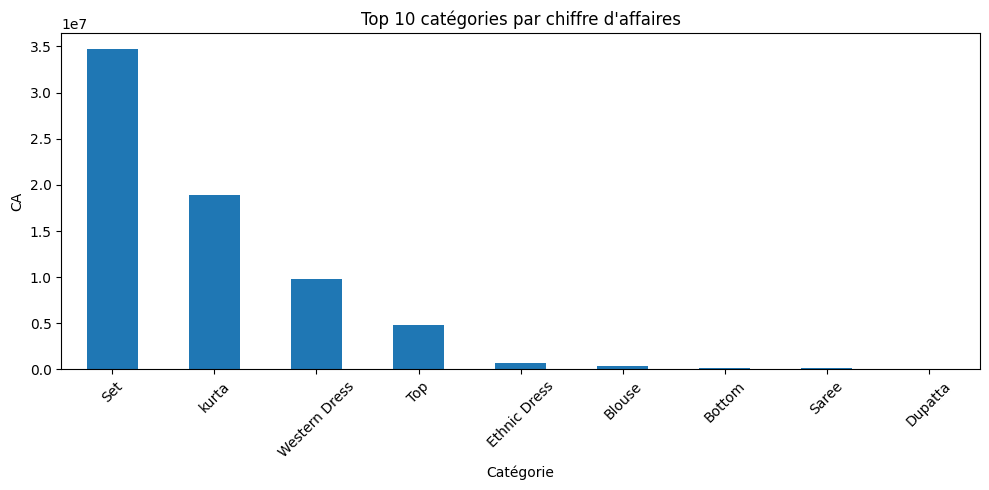

In [44]:
# Crée un graphique en barres sur les 10 premières catégories
revenue_by_category.head(10).plot(kind="bar", figsize=(10, 5))

# Titre du graphique
plt.title("Top 10 catégories par chiffre d'affaires")

# Nom de l'axe horizontal
plt.xlabel("Catégorie")

# Nom de l'axe vertical
plt.ylabel("CA")

# Rotation des labels pour mieux lire les catégories
plt.xticks(rotation=45)

# Ajuste les marges automatiquement
plt.tight_layout()

# Affiche le graphique
plt.show()

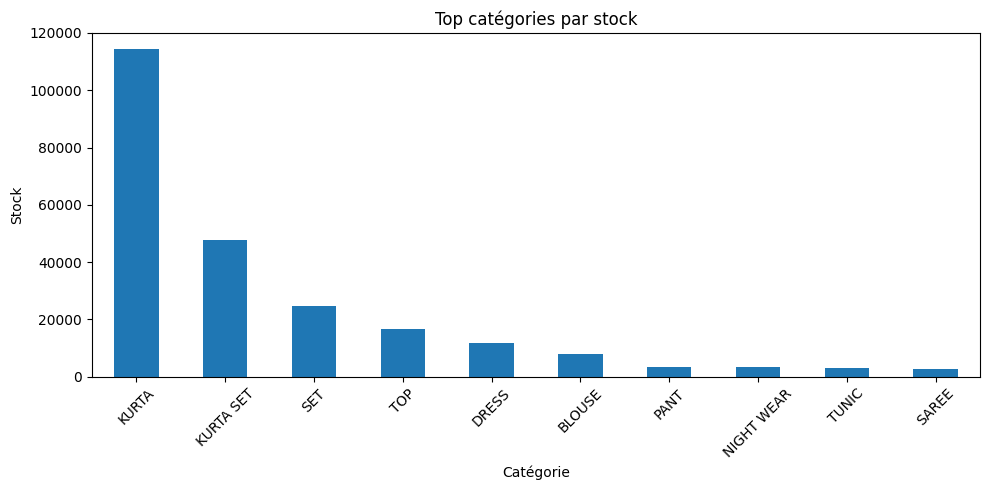

In [45]:
# Graphique des catégories ayant le plus de stock
stock_by_category.head(10).plot(kind="bar", figsize=(10, 5))

plt.title("Top catégories par stock")
plt.xlabel("Catégorie")
plt.ylabel("Stock")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

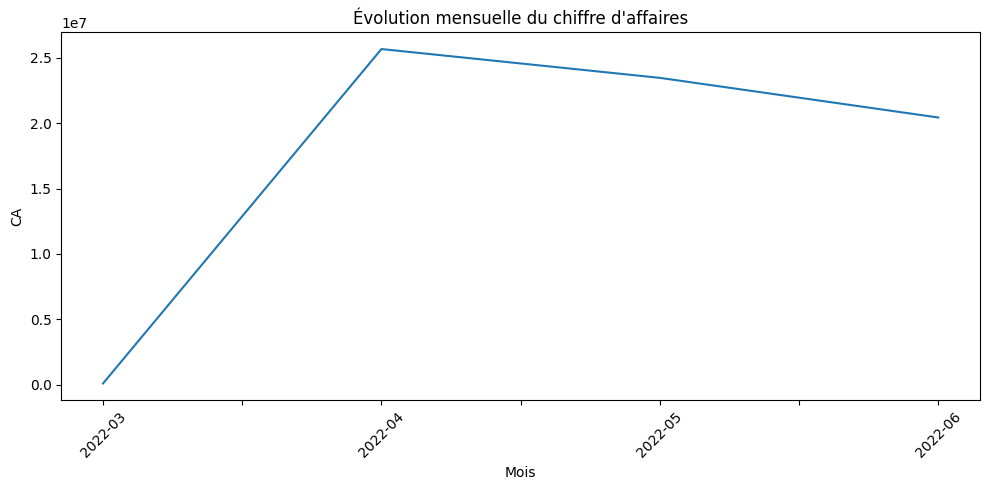

In [46]:
# Graphique en ligne de l'évolution du CA par mois
monthly_revenue.plot(figsize=(10, 5))

plt.title("Évolution mensuelle du chiffre d'affaires")
plt.xlabel("Mois")
plt.ylabel("CA")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

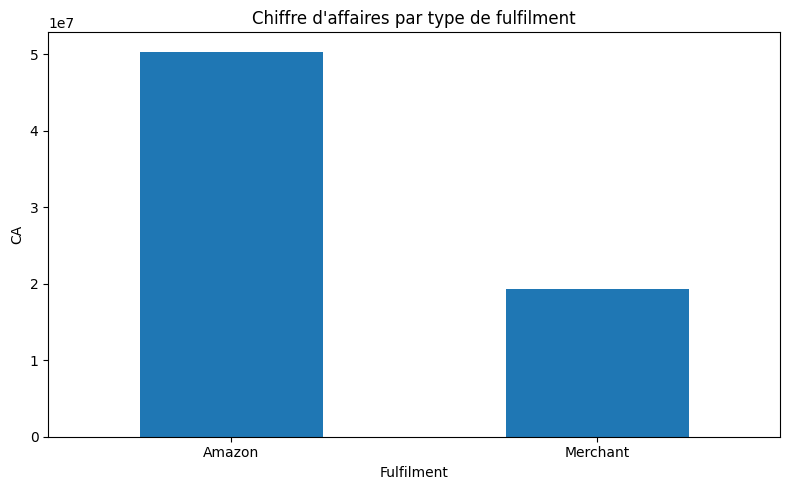

In [47]:
# Graphique en barres du chiffre d'affaires par type de fulfilment
revenue_by_fulfilment.plot(kind="bar", figsize=(8, 5))

plt.title("Chiffre d'affaires par type de fulfilment")
plt.xlabel("Fulfilment")
plt.ylabel("CA")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

<Axes: xlabel='Category'>

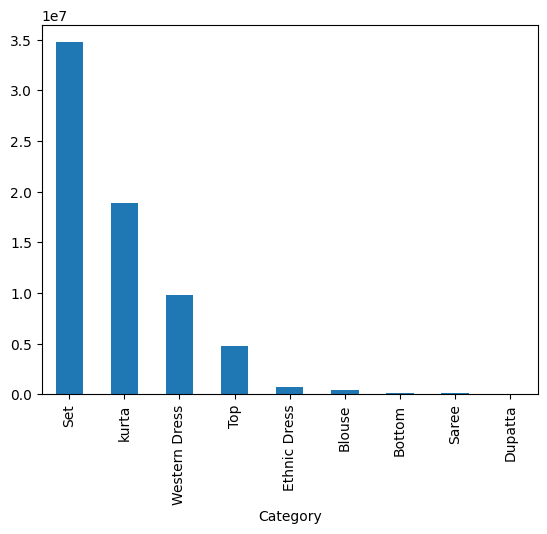

In [48]:
revenue_by_category.plot(kind="bar")

<Axes: xlabel='Fulfilment'>

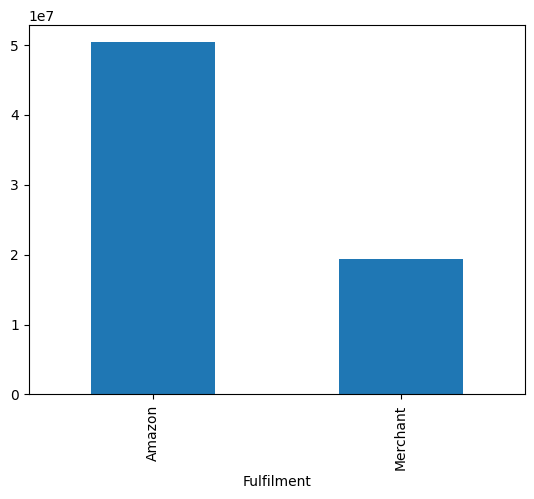

In [50]:
revenue_by_fulfilment.plot(kind="bar")

In [ ]:
## Conclusion

#L'analyse met en évidence plusieurs points importants :

#- Le taux d'annulation est élevé (~14 %)
#- Le taux de retour reste relativement faible (~1.6 %)
#- La majorité du chiffre d'affaires est générée via la logistique Amazon
#- Certaines catégories représentent une part très importante du stock

#Ces éléments suggèrent que les annulations constituent le principal facteur
#de perte de revenu.